# Laboratorio Final — Starbucks Rewards: del experimento a la decisión

Cierra el bloque de Churn y Uplift Modeling. Van a trabajar con la campaña COMPLETA (no una
muestra de prueba): 40,000 clientes, mitad recibió un cupón de $5 (tratamiento), mitad no
(control), medidos a 60 días.

Este laboratorio repite, sobre la base completa, lo que ya practicaron en los Breakout Rooms:

| Dónde lo vieron | Qué van a repetir aquí |
|---|---|
| Breakout 2 — Las dos ventanas | Un modelo de riesgo/churn, para targetear y ver la pérdida |
| Breakout 3 — Los 4 cuadrantes | El T-learner: dos modelos, uno por grupo |
| Breakout 4 — La curva Qini | Miden qué tan bien ordena su T-learner con datos que nunca vio |

Las columnas `recency_days`, `frequency` y `monetary` son las mismas del RFM de la Semana 1.

**Los 3 pasos del laboratorio:**
1. Entrenan un modelo de churn y lo usan para targetear — van a ver la pérdida con sus
   propios números.
2. Programan el T-learner y miden su Qini.
3. Deciden a quién contactar: eligen el porcentaje óptimo y defienden la cifra.

El dataset trae una columna oculta con el **tipo real de cada cliente y su uplift
verdadero** — en la vida real esa columna no existe. Al final del laboratorio la van a
destapar para ver si sus modelos acertaron.

Donde dice **`# TODO`** hay algo para que ustedes completen.


In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/uplift_campaign.csv")
print(f"{len(df):,} clientes · {(df['treatment_group']=='treatment').sum():,} tratados · {(df['treatment_group']=='control').sum():,} control")
df.head()


40,000 clientes · 19,921 tratados · 20,079 control


,customer_id,treatment_group,recency_days,frequency,monetary,email_open_rate,tenure_days,responded_60d,value_60d,margin_60d,utilidad_neta_60d
0,1,treatment,15,25,615.42,0.230,998,1,38.86,9.72,4.67
1,2,control,30,7,196.12,0.231,551,1,57.20,14.30,14.30
2,3,control,37,1,151.60,0.428,508,0,0.00,0.00,0.00
3,4,control,0,16,449.54,0.386,733,1,24.21,6.05,6.05
4,5,treatment,20,10,393.00,0.796,734,1,23.62,5.91,0.86


## Paso 1 — entrenen un modelo de churn y usen para targetear

Un modelo de churn normal: no sabe nada de tratamiento/control, solo aprende a predecir quién
NO va a volver a comprar. Lo van a usar para elegir a quién contactar (targeting por riesgo) y
van a medir qué tan bien o mal les fue con esa decisión, usando el experimento real como juez.


In [2]:
FEATURES = ["recency_days", "frequency", "monetary", "email_open_rate", "tenure_days"]

train, test = train_test_split(df, test_size=0.30, random_state=42, stratify=df["treatment_group"])

train_churn = train.copy()
train_churn["churned"] = 1 - train_churn["responded_60d"]

# Modelo de riesgo/churn entrenado con SOLO los datos de entrenamiento
modelo_riesgo = LogisticRegression(max_iter=1000).fit(train_churn[FEATURES], train_churn["churned"])

test = test.copy()
test["prob_churn"] = modelo_riesgo.predict_proba(test[FEATURES])[:, 1]
print("Modelo de riesgo entrenado")


Modelo de riesgo entrenado


Ahora midan el valor real de targetear por riesgo: tomen el 30% con mayor probabilidad de
churn en el conjunto de prueba, y comparen el valor neto (`utilidad_neta_60d` para los
tratados de ese grupo, contra `margin_60d` del control de ese mismo grupo — su "costo de no
hacer nada").


In [3]:
def valor_de_la_politica(test_df, seleccionados):
    # Valor NETO: margen bruto menos el costo del cupón ($5, solo si compró) y el envío
    # ($0.05, por cualquier tratado) -- la misma fórmula de la slide "El experimento".
    sel = test_df.loc[seleccionados]
    valor_tratado = sel.loc[sel["treatment_group"] == "treatment", "utilidad_neta_60d"].mean()
    valor_control = sel.loc[sel["treatment_group"] == "control", "margin_60d"].mean()
    return valor_tratado - valor_control, len(sel)

n_contactar = int(len(test) * 0.30)
idx_riesgo = test.sort_values("prob_churn", ascending=False).head(n_contactar).index
uplift_riesgo, n_riesgo = valor_de_la_politica(test, idx_riesgo)
print(f"Targeting por riesgo: ${uplift_riesgo:+.2f}/cliente sobre {n_riesgo:,} clientes (total ${uplift_riesgo*n_riesgo:+,.2f})")


Targeting por riesgo: $+0.07/cliente sobre 3,600 clientes (total $+245.40)


**Respuesta Paso 1.** Targetear al 30% de mayor riesgo deja apenas **+$0.07 por cliente (≈ +$245 en 3,600 clientes)**: prácticamente cero. El modelo de churn identifica bien a quién se va a ir, pero ese grupo está dominado por *Lost Causes* (ver la revelación final: 71% del top 30% por riesgo), que no vuelven con o sin cupón. Riesgo alto ≠ vale la pena contactar.

## Paso 2 — programen el T-learner y midan su Qini

Dos modelos de **Regresión Logística**: uno entrenado SOLO con los clientes tratados de entrenamiento, otro SOLO con los
de control. Le preguntan a los dos sobre el conjunto de prueba completo, y restan.


In [4]:
train_t = train[train["treatment_group"] == "treatment"]
train_c = train[train["treatment_group"] == "control"]

# T-learner: un modelo por grupo
modelo_tratado = LogisticRegression(max_iter=1000).fit(train_t[FEATURES], train_t["responded_60d"])
modelo_control = LogisticRegression(max_iter=1000).fit(train_c[FEATURES], train_c["responded_60d"])

X_test = test[FEATURES]
# Puntuar el conjunto de prueba con ambos modelos
test["p_tratado"] = modelo_tratado.predict_proba(X_test)[:, 1]
test["p_control"] = modelo_control.predict_proba(X_test)[:, 1]
test["uplift_estimado"] = test["p_tratado"] - test["p_control"]

print("T-learner entrenado y conjunto de prueba puntuado")


T-learner entrenado y conjunto de prueba puntuado


In [5]:
def curva_qini(test_df, score_col, steps=40):
    orden = test_df.sort_values(score_col, ascending=False).reset_index(drop=True)
    es_tratado = (orden["treatment_group"] == "treatment").values
    respondio = orden["responded_60d"].values

    acumulado_tratados = np.cumsum(np.where(es_tratado, respondio, 0))
    acumulado_control = np.cumsum(np.where(~es_tratado, respondio, 0))
    n_tratados_acum = np.cumsum(es_tratado)
    n_control_acum = np.cumsum(~es_tratado)

    n = len(orden)
    xs, ys = [0.0], [0.0]
    for i in np.linspace(1, n, steps).astype(int):
        nt, nc = n_tratados_acum[i - 1], n_control_acum[i - 1]
        tasa_t = acumulado_tratados[i - 1] / nt if nt > 0 else 0
        tasa_c = acumulado_control[i - 1] / nc if nc > 0 else 0
        xs.append(i / n)
        ys.append((tasa_t - tasa_c) * n)
    return np.array(xs), np.array(ys)


def coeficiente_qini(xs, ys, n):
    area_modelo = np.trapezoid(ys, xs)
    area_azar = np.trapezoid(np.linspace(0, ys[-1], len(xs)), xs)
    return (area_modelo - area_azar) / n


xs_uplift, ys_uplift = curva_qini(test, "uplift_estimado")
xs_riesgo, ys_riesgo = curva_qini(test, "prob_churn")
qini_uplift = coeficiente_qini(xs_uplift, ys_uplift, len(test))
qini_riesgo = coeficiente_qini(xs_riesgo, ys_riesgo, len(test))

print(f"Coeficiente Qini · T-learner:       {qini_uplift:+.3f}")
print(f"Coeficiente Qini · riesgo/churn:    {qini_riesgo:+.3f}")


Coeficiente Qini · T-learner:       +0.142
Coeficiente Qini · riesgo/churn:    +0.048


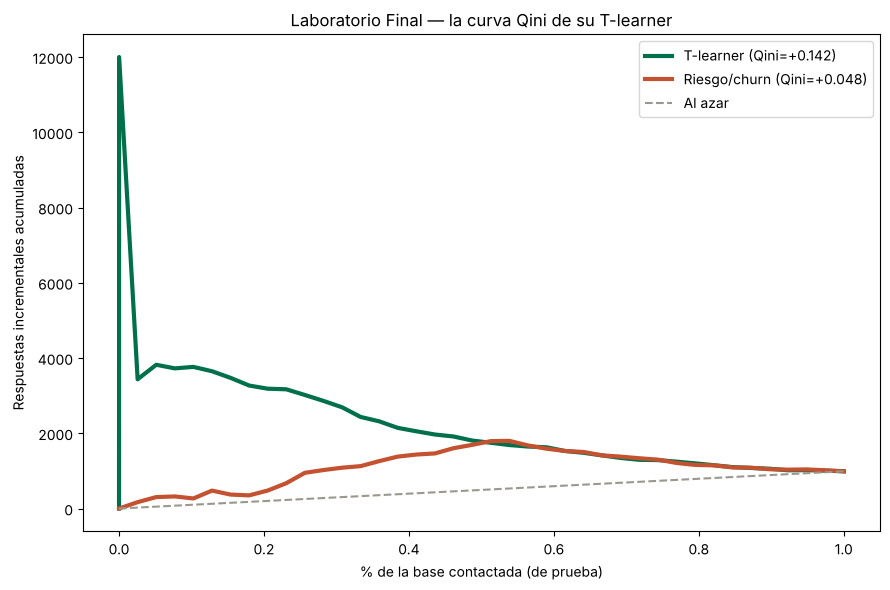

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(xs_uplift, ys_uplift, color="#00704A", linewidth=3, label=f"T-learner (Qini={qini_uplift:+.3f})")
ax.plot(xs_riesgo, ys_riesgo, color="#C4512F", linewidth=3, label=f"Riesgo/churn (Qini={qini_riesgo:+.3f})")
ax.plot([0, 1], [0, ys_uplift[-1]], color="#9A988E", linestyle="--", label="Al azar")
ax.set_xlabel("% de la base contactada (de prueba)")
ax.set_ylabel("Respuestas incrementales acumuladas")
ax.set_title("Laboratorio Final — la curva Qini de su T-learner")
ax.legend()
plt.tight_layout()
plt.savefig("curva_qini_laboratorio.png", dpi=150)
plt.show()


**Respuesta Paso 2.** El T-learner logístico obtiene un **Qini de +0.142** contra **+0.048** del modelo de riesgo: ordena casi 3 veces mejor a los clientes por efecto causal. La curva verde se despega de la diagonal desde el primer 10–20% y cae después, señal de que al final de la lista hay clientes con uplift negativo (Sleeping Dogs) donde contactar resta.

## Paso 3 — decidan a quién contactar

Prueben varios porcentajes de la base (10%, 20%, ..., 100%) ordenados por `uplift_estimado`, y
para cada uno calculen el valor neto total (usando `value_60d`, igual que en el Paso 2).
Encuentren el porcentaje que deja más dinero sobre la mesa.


In [7]:
resultados = []
for pct in range(10, 101, 10):
    n_c = int(len(test) * pct / 100)
    idx = test.sort_values("uplift_estimado", ascending=False).head(n_c).index
    valor_cliente, n = valor_de_la_politica(test, idx)
    resultados.append({"pct_contactado": pct, "valor_por_cliente": round(valor_cliente, 2), "n_contactados": n, "valor_total": round(valor_cliente * n, 2)})

tabla_politicas = pd.DataFrame(resultados)
tabla_politicas


,pct_contactado,valor_por_cliente,n_contactados,valor_total
0,10,1.62,1200,1948.93
1,20,0.99,2400,2368.51
2,30,0.46,3600,1673.33
3,40,-0.10,4800,-500.97
4,50,-0.48,6000,-2899.72
5,60,-0.73,7200,-5260.88
6,70,-0.93,8400,-7853.02
7,80,-1.17,9600,-11226.84
8,90,-1.45,10800,-15687.26
9,100,-1.69,12000,-20236.13


In [8]:
# Afinamos alrededor del óptimo con pasos de 5%
fino = []
for pct in range(5, 51, 5):
    n_c = int(len(test) * pct / 100)
    idx = test.sort_values("uplift_estimado", ascending=False).head(n_c).index
    v, n = valor_de_la_politica(test, idx)
    fino.append({"pct_contactado": pct, "valor_por_cliente": round(v, 2), "n_contactados": n, "valor_total": round(v * n, 2)})
pd.DataFrame(fino)

,pct_contactado,valor_por_cliente,n_contactados,valor_total
0,5,1.60,600,960.47
1,10,1.62,1200,1948.93
2,15,1.34,1800,2408.01
3,20,0.99,2400,2368.51
4,25,0.82,3000,2453.53
5,30,0.46,3600,1673.33
6,35,0.18,4200,741.34
7,40,-0.10,4800,-500.97
8,45,-0.30,5400,-1631.92
9,50,-0.48,6000,-2899.72


**Pregunta para defender con su propia cifra:** ¿cuál % maximiza el valor TOTAL? ¿Es el mismo
que maximiza el valor POR CLIENTE? ¿Por qué no, necesariamente?


**Respuesta Paso 3.**
- **Valor TOTAL máximo:** entre 15% y 25% de la base (≈ $2,370–$2,450 en el conjunto de prueba). Con pasos de 10% el óptimo es **20%**; con pasos de 5% la curva es plana en esa zona (las diferencias de ±$80 están dentro del ruido estadístico). Recomendación: **20%**.
- **Valor POR CLIENTE máximo:** 10% (+$1.62/cliente). No es el mismo porcentaje.
- **¿Por qué no coinciden?** El valor por cliente baja conforme bajamos en la lista (cada cliente adicional es menos persuadable), pero mientras ese valor marginal siga siendo positivo, el total sigue creciendo. El total se maximiza justo donde el cliente marginal deja de aportar (≈ 20–25%); a partir del 40% el valor por cliente es negativo y contactar a todos **pierde $20,236** en la muestra de prueba.

## La revelación final

Esta es la parte que no pudieron hacer en los Breakout Rooms: el dataset completo
(`uplift_campaign_FULL.csv`) trae el **tipo real** de cada cliente y su **uplift verdadero** —
información que en la vida real nunca existe. Compárenla contra lo que su modelo estimó.


In [9]:
full = pd.read_csv("uplift_campaign_FULL.csv")
full_test = full[full["customer_id"].isin(test["customer_id"])].merge(
    test[["customer_id", "uplift_estimado", "prob_churn"]], on="customer_id"
)

print("Composición real de la base de prueba:")
print((full_test["true_type"].value_counts(normalize=True) * 100).round(1))
print()
print("Correlación entre uplift ESTIMADO y uplift VERDADERO:", round(full_test["uplift_estimado"].corr(full_test["true_uplift_prob"]), 3))


Composición real de la base de prueba:
true_type
sure_thing      48.9
persuadable     22.4
lost_cause      21.5
sleeping_dog     7.2
Name: proportion, dtype: float64

Correlación entre uplift ESTIMADO y uplift VERDADERO: 0.619


In [10]:
# Comparación por tipo real: ¿el modelo ordena a cada cuadrante donde debe?
print(full_test.groupby("true_type")[["uplift_estimado", "true_uplift_prob", "prob_churn"]].mean().round(3))

# Composición del 30% elegido por RIESGO vs. el top elegido por UPLIFT (20%)
top_riesgo = full_test.nlargest(int(len(full_test)*0.30), "prob_churn")
top_uplift = full_test.nlargest(int(len(full_test)*0.20), "uplift_estimado")
comp = pd.DataFrame({
    "Base de prueba %": full_test["true_type"].value_counts(normalize=True)*100,
    "Top 30% por riesgo %": top_riesgo["true_type"].value_counts(normalize=True)*100,
    "Top 20% por uplift %": top_uplift["true_type"].value_counts(normalize=True)*100,
}).fillna(0).round(1)
print(); print(comp)
print("\nCorrelación prob_churn vs uplift verdadero:", round(full_test["prob_churn"].corr(full_test["true_uplift_prob"]), 3))

              uplift_estimado  true_uplift_prob  prob_churn
true_type                                                  
lost_cause              0.062             0.020       0.921
persuadable             0.175             0.350       0.634
sleeping_dog            0.090            -0.150       0.641
sure_thing              0.023             0.004       0.244

              Base de prueba %  Top 30% por riesgo %  Top 20% por uplift %
true_type                                                                 
lost_cause                21.5                  71.0                   4.4
persuadable               22.4                  22.5                  80.0
sleeping_dog               7.2                   6.6                   3.2
sure_thing                48.9                   0.0                  12.4

Correlación prob_churn vs uplift verdadero: 0.227


**Respuesta — revelación final.**
- La correlación entre uplift estimado y verdadero es **0.619**: el modelo captura bien la dirección, no la magnitud (subestima a los Persuadables: 0.175 estimado vs 0.350 real).
- El **top 20% por uplift es 80% Persuadables**, contra 22% en la base: el modelo concentra el presupuesto donde debe.
- El **top 30% por riesgo es 71% Lost Causes** y casi el mismo % de Persuadables que la base (22.5%): por eso su valor fue ~$0.
- **Debilidad clara:** la logística le asigna a los *Sleeping Dogs* un uplift promedio de +0.09 cuando el real es −0.15. No detecta el efecto negativo; por eso todavía se cuelan 3.2% de Sleeping Dogs en el top 20%.

## Paso 4 — comparación de modelos base dentro del T-learner

Mismo T-learner, mismo split, cambiando solo el clasificador. Se controla el sobreajuste con `max_depth` y `min_samples_leaf`.

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

true_uplift = full.set_index("customer_id").loc[test["customer_id"], "true_uplift_prob"].values

modelos = {
    "Logística (la del notebook)": lambda: LogisticRegression(max_iter=1000),
    "Árbol sin límite": lambda: DecisionTreeClassifier(random_state=42),
    "Árbol con max_depth=2": lambda: DecisionTreeClassifier(max_depth=2, random_state=42),
    "Árbol max_depth=5, min_samples_leaf=200": lambda: DecisionTreeClassifier(max_depth=5, min_samples_leaf=200, random_state=42),
    "Random Forest (300 árboles, max_depth=6, min_samples_leaf=100)": lambda: RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=100, random_state=42, n_jobs=-1),
    "Gradient Boosting (200, max_depth=3, lr=0.05)": lambda: GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, min_samples_leaf=100, random_state=42),
}

filas = []
for nombre, fabrica in modelos.items():
    m_t = fabrica().fit(train_t[FEATURES], train_t["responded_60d"])
    m_c = fabrica().fit(train_c[FEATURES], train_c["responded_60d"])
    t2 = test.copy()
    t2["u"] = m_t.predict_proba(X_test)[:, 1] - m_c.predict_proba(X_test)[:, 1]
    xs, ys = curva_qini(t2, "u")
    mejor = max(
        ((p,) + valor_de_la_politica(t2, t2.sort_values("u", ascending=False).head(int(len(t2)*p/100)).index) for p in range(10, 101, 10)),
        key=lambda r: r[1] * r[2])
    filas.append({
        "Modelo dentro del T-learner": nombre,
        "Correlación con el uplift real": round(np.corrcoef(t2["u"], true_uplift)[0, 1], 3),
        "Qini": round(coeficiente_qini(xs, ys, len(t2)), 3),
        "% óptimo": mejor[0],
        "Valor total óptimo ($)": round(mejor[1] * mejor[2], 0),
    })

tabla_modelos = pd.DataFrame(filas)
tabla_modelos.to_csv("tabla_comparacion_modelos.csv", index=False)
tabla_modelos

,Modelo dentro del T-learner,Correlación con el uplift real,Qini,% óptimo,Valor total óptimo ($)
0,Logística (la del notebook),0.619,0.142,20,2369.0
1,Árbol sin límite,0.204,0.066,10,-862.0
2,Árbol con max_depth=2,0.605,0.112,20,2160.0
3,"Árbol max_depth=5, min_samples_leaf=200",0.753,0.152,20,3859.0
4,"Random Forest (300 árboles, max_depth=6, min_s...",0.857,0.157,20,4434.0
5,"Gradient Boosting (200, max_depth=3, lr=0.05)",0.848,0.156,20,4485.0


**Respuesta Paso 4 — comparación de modelos.**
- **Árbol sin límite** es el peor (corr 0.20, Qini 0.066, valor negativo): sobreajusta, y en un T-learner el ruido de los dos modelos se suma al restar.
- **Árbol max_depth=2** queda cerca de la logística pero por debajo: muy simple para capturar interacciones.
- **Random Forest y Gradient Boosting regularizados** son los mejores: correlación ≈ **0.85** (vs 0.62) y Qini ≈ **0.157** (vs 0.142). Lo más relevante para negocio: casi **duplican el valor total** al 20% (≈ $4,450 vs $2,370 en prueba).
- El % óptimo es **20% en todos los modelos razonables**: la recomendación es robusta al modelo; lo que cambia es cuánto dinero deja.
- Elección: **Random Forest** (mayor correlación con el uplift real; Gradient Boosting es prácticamente equivalente).

## Para entregar

1. El notebook completo, ejecutado de principio a fin, con sus respuestas a las preguntas de
   cada paso.
2. **Su propia app de Streamlit** (usen `streamlit_starter.py` como punto de partida) que le
   permita a alguien de negocio explorar: el Qini del T-learner y la tabla de
   políticas del Paso 3 — con al menos un control interactivo (slider o selector).
3. Una conclusión de una página: ¿a qué porcentaje de la base contactarían, y por qué? Usen la
   comparación final para decir qué tan cerca estuvo su modelo de la verdad.
4. Cambien el modelo base del T-learner (Árbol de decisión, Random Forest, Gradient Boosting, SVM…) y comparen contra la logística. Cuiden el sobreajuste, por ejemplo con max_depth o min_samples_leaf. ¿Cuál mejora más la correlación del Uplift y el Qini index?
